# Model Evaluation

This notebook evaluates the trained Random Forest model on the test set.
The goal is to measure how well the model predicts loan default.


In [1]:
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

with open("../models/rf_model.pkl", "rb") as f:
    model = pickle.load(f)


## Predictions

I generate predicted classes and predicted probabilities.
The probabilities are useful for metrics like ROC AUC.


In [2]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


## Performance metrics

I use a classification report to check precision, recall, and F1-score.
These metrics are more informative than accuracy alone for classification tasks.


In [3]:
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4486
           1       0.97      0.72      0.82      1241

    accuracy                           0.93      5727
   macro avg       0.95      0.86      0.89      5727
weighted avg       0.94      0.93      0.93      5727

ROC AUC: 0.9318604428927961


## Confusion matrix

The confusion matrix shows how many predictions were correct and where the model made mistakes.
This is useful to understand false positives and false negatives.


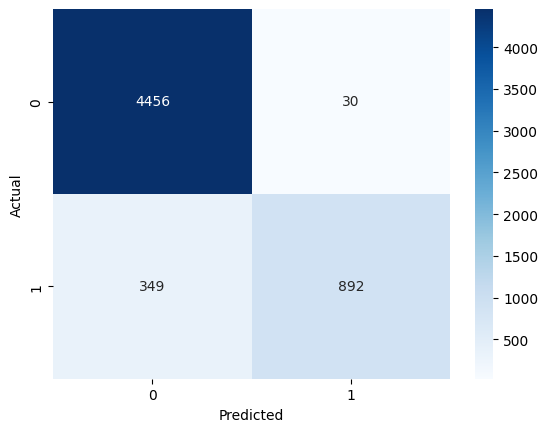

In [4]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


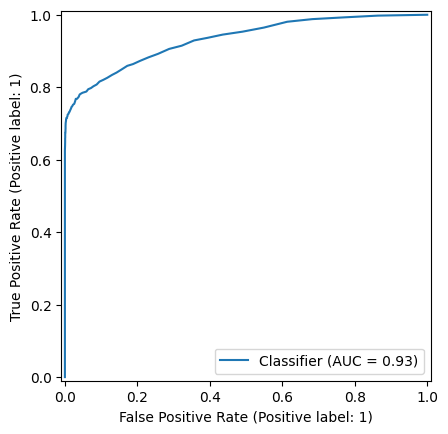

In [5]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()


## Conclusion

The Random Forest model achieves an overall accuracy of about 93%, which indicates strong performance on the test set.  
Looking at the class-wise metrics, the model performs very well on non-default cases (class 0) with high precision (0.93), recall (0.99), and F1-score (0.96).  

For default cases (class 1), precision is also high at 0.97, meaning that when the model predicts a default, it is usually correct.  
However, recall for class 1 is lower (0.72), which shows that some true defaults are still being missed by the model.  

The confusion matrix confirms this: there are 892 true positives and 349 false negatives, compared to only 30 false positives and 4456 true negatives.  
From a business perspective, missing a default (false negative) is usually more costly than incorrectly flagging a non-default as risky (false positive), so improving recall for class 1 could be an important next step.  

Finally, the ROC AUC score of about 0.93 indicates that the model separates default vs. non-default cases very well across different decision thresholds.  
Overall, the model is strong, but further tuning could focus on reducing false negatives (increasing recall for class 1), for example by adjusting the classification threshold or using class weights.
